In [49]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Model Selection & Evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,ConfusionMatrixDisplay
)

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
# Statistical testing
from scipy import stats

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE





In [38]:
# Define paths
artifact_path = Path("preprocessing_artifacts")

print("=" * 80)
print("LOADING PREPROCESSED DATA")
print("=" * 80)

# ============================================
# CONFIGURATION: FEATURE FILTERING
# ============================================
USE_FEATURE_FILTERING = False  # Set to False to use all features

print(f"\n⚙️  CONFIGURATION:")
print(f"   Feature Filtering: {'ENABLED' if USE_FEATURE_FILTERING else 'DISABLED'}")

# Define feature columns to use (only used if filtering is enabled)
audio_features_cols = ['Speechiness', 'Danceability', 'Valence', 'Loudness_norm']
artist_features_cols = ['artist_song_count', 
                        'artist_avg_rank',
                        'artist_best_rank']

temporal_features_cols = ['is_friday_release']

# Combine all selected features
selected_features = audio_features_cols + artist_features_cols + temporal_features_cols

if USE_FEATURE_FILTERING:
    print(f"\n📋 Selected Features ({len(selected_features)} total):")
    print(f"   Audio Features ({len(audio_features_cols)}): {audio_features_cols}")
    print(f"   Artist Features ({len(artist_features_cols)}): {artist_features_cols}")
    print(f"   Temporal Features ({len(temporal_features_cols)}): {temporal_features_cols}")

# Load Baseline (Scaled) data
X_train_baseline_full = pd.read_csv(artifact_path / "X_train_baseline.csv")
X_val_baseline_full = pd.read_csv(artifact_path / "X_val_baseline.csv")
X_test_baseline_full = pd.read_csv(artifact_path / "X_test_baseline.csv")

# Apply filtering based on configuration
if USE_FEATURE_FILTERING:
    # Filter to only selected features
    X_train_baseline = X_train_baseline_full[selected_features]
    X_val_baseline = X_val_baseline_full[selected_features]
    X_test_baseline = X_test_baseline_full[selected_features]

    # Verify all selected features are present
    missing_features = set(selected_features) - set(X_train_baseline.columns)
    if missing_features:
        print(f"\n⚠️  WARNING: Missing features in baseline: {missing_features}")
    else:
        print(f"\n✅ All {len(selected_features)} selected features found and filtered")
else:
    # Use all features
    X_train_baseline = X_train_baseline_full.copy()
    X_val_baseline = X_val_baseline_full.copy()
    X_test_baseline = X_test_baseline_full.copy()

    print(f"\n✅ Using all {X_train_baseline.shape[1]} features (no filtering)")

# Load L1 Selected Features data
X_train_L1 = pd.read_csv(artifact_path / "X_train_L1.csv")
X_val_L1 = pd.read_csv(artifact_path / "X_val_L1.csv")
X_test_L1 = pd.read_csv(artifact_path / "X_test_L1.csv")

# Load PCA data
X_train_pca = pd.read_csv(artifact_path / "X_train_pca.csv")
X_val_pca = pd.read_csv(artifact_path / "X_val_pca.csv")
X_test_pca = pd.read_csv(artifact_path / "X_test_pca.csv")


# Load target variables
y_train = pd.read_csv(artifact_path / "y_train.csv")
y_val = pd.read_csv(artifact_path / "y_val.csv")
y_test = pd.read_csv(artifact_path / "y_test.csv")

# Convert target to binary (if not already)
y_train_array = y_train['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values
y_val_array = y_val['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values
y_test_array = y_test['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values

print("\n✅ Data loaded successfully!\n")
print(f"Baseline {'(filtered)' if USE_FEATURE_FILTERING else '(all features)'}: X_train={X_train_baseline.shape}, X_val={X_val_baseline.shape},X_test={X_test_baseline.shape}")
print(f"L1 Selection:        X_train={X_train_L1.shape}, X_val={X_val_L1.shape}, X_test={X_test_L1.shape}")
print(f"PCA:                 X_train={X_train_pca.shape}, X_val={X_val_pca.shape},X_test={X_test_pca.shape}")
print(f"Target:              y_train={y_train_array.shape}, y_val={y_val_array.shape}, y_test={y_test_array.shape}")

print("\nClass distribution:")
print(f"  Training:   {np.bincount(y_train_array)}")
print(f"  Validation: {np.bincount(y_val_array)}")
print(f"  Test: {np.bincount(y_test_array)}")

print("=" * 80)

LOADING PREPROCESSED DATA

⚙️  CONFIGURATION:
   Feature Filtering: DISABLED

✅ Using all 20 features (no filtering)

✅ Data loaded successfully!

Baseline (all features): X_train=(6158, 20), X_val=(1414, 20),X_test=(1589, 20)
L1 Selection:        X_train=(6158, 10), X_val=(1414, 10), X_test=(1589, 10)
PCA:                 X_train=(6158, 13), X_val=(1414, 13),X_test=(1589, 13)
Target:              y_train=(6158,), y_val=(1414,), y_test=(1589,)

Class distribution:
  Training:   [4310 1848]
  Validation: [1015  399]
  Test: [1140  449]


In [24]:
smote = SMOTE(random_state=42, sampling_strategy='auto')

# SMOTE for Baseline
X_train_baseline_smote, y_train_baseline_smote = smote.fit_resample(X_train_baseline, y_train_array)
print(f"Baseline SMOTE - Original: {X_train_baseline.shape}, After SMOTE: {X_train_baseline_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_baseline_smote)}")

# SMOTE for L1
X_train_L1_smote, y_train_L1_smote = smote.fit_resample(X_train_L1, y_train_array)
print(f"\nL1 SMOTE - Original: {X_train_L1.shape}, After SMOTE: {X_train_L1_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_L1_smote)}")

# SMOTE for PCA
X_train_pca_smote, y_train_pca_smote = smote.fit_resample(X_train_pca, y_train_array)
print(f"\nPCA SMOTE - Original: {X_train_pca.shape}, After SMOTE: {X_train_pca_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_pca_smote)}")

# Create a dictionary for SMOTE datasets (for later use)
datasets_smote = {
    'Baseline': (X_train_baseline_smote, X_val_baseline, y_train_baseline_smote),
    'L1': (X_train_L1_smote, X_val_L1, y_train_L1_smote),
    'PCA': (X_train_pca_smote, X_val_pca, y_train_pca_smote)
}

print("\n✅ SMOTE applied successfully to all preprocessing methods!")

Baseline SMOTE - Original: (6158, 20), After SMOTE: (8620, 20)
  Class distribution: [4310 4310]

L1 SMOTE - Original: (6158, 10), After SMOTE: (8620, 10)
  Class distribution: [4310 4310]

PCA SMOTE - Original: (6158, 13), After SMOTE: (8620, 13)
  Class distribution: [4310 4310]

✅ SMOTE applied successfully to all preprocessing methods!


In [25]:
def get_models_for_tuning():
    return {
        'Logistic Regression': LogisticRegression(
            penalty='l2', max_iter=2000, random_state=42
        ),
        'SVM (Linear)': SVC(
            kernel='linear', probability=True,
            random_state=42, max_iter=3000
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', probability=True,
            random_state=42, max_iter=3000
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200,random_state=42, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': XGBClassifier(
            eval_metric='logloss', random_state=42, n_jobs=-1, tree_method='hist'
        )
    }

In [26]:
param_grids = {
    'Logistic Regression': {
        'C': [0.05, 0.1, 1, 5, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'SVM (Linear)': {
        'C': [0.1, 1, 10]
    },
    'SVM (RBF)': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01, 0.1]
    },
    'Random Forest': {
        'n_estimators': [200, 400],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [2, 3, 4]
    },
    'XGBoost': {
        'n_estimators': [200, 400],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8],
        'subsample': [0.7, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0],
        'reg_lambda': [0.5, 1.0, 2.0],
        'reg_alpha': [0, 0.1, 0.5]
    }
}

In [27]:
def find_best_threshold(y_true, proba):
    ts = np.linspace(0.05, 0.95, 37)
    best_t, best_f1 = 0.5, -1
    for t in ts:
        pred = (proba >= t).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def tune_one_model(name, model, Xtr, ytr, Xva, yva, scoring='roc_auc'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gs = GridSearchCV(model, param_grids[name], scoring=scoring, cv=cv, n_jobs=-1, refit=True, verbose=0)
    gs.fit(Xtr, ytr)
    best_est = gs.best_estimator_

    if hasattr(best_est, 'predict_proba'):
        proba = best_est.predict_proba(Xva)[:, 1]
    elif hasattr(best_est, 'decision_function'):
        proba = best_est.decision_function(Xva)
    else:
        proba = None

    pred_05 = best_est.predict(Xva)
    roc = roc_auc_score(yva, proba) if proba is not None else np.nan
    f1_05 = f1_score(yva, pred_05)
    acc_05 = accuracy_score(yva, pred_05)
    pre_05 = precision_score(yva, pred_05, zero_division=0)
    rec_05 = recall_score(yva, pred_05)

    best_t, f1_best = 0.5, f1_05

    return {
        'best_estimator': best_est, 'best_params': gs.best_params_,
        'val_roc_auc': roc, 'val_f1@0.5': f1_05, 'val_acc@0.5': acc_05,
        'val_prec@0.5': pre_05, 'val_recall@0.5': rec_05,
        'best_t': best_t, 'val_f1@best_t': f1_best
    }

In [28]:
def run_all_tuning(datasets_smote, y_val_array, scoring='roc_auc'):
    models = get_models_for_tuning()
    rows, best_models = [], {}
    for feat_name, (Xtr, Xva, ytr) in datasets_smote.items():
        for mname, model in models.items():
            print(f"=== {feat_name} | {mname} ===")
            out = tune_one_model(mname, model, Xtr, ytr, Xva, y_val_array, scoring=scoring)
            rows.append({'feature_set': feat_name, 'model': mname, 'best_params': out['best_params'],
                         'val_roc_auc': out['val_roc_auc'], 'val_f1@0.5': out['val_f1@0.5'],
                         'val_f1@best_t': out['val_f1@best_t'], 'best_t': out['best_t'],
                         'val_acc@0.5': out['val_acc@0.5'], 'val_prec@0.5': out['val_prec@0.5'],
                         'val_recall@0.5': out['val_recall@0.5']})
            best_models[(feat_name, mname)] = (out['best_estimator'], out['best_t'])
    return pd.DataFrame(rows).sort_values(by=['val_roc_auc','val_f1@best_t'], ascending=False), best_models

results_df, best_models = run_all_tuning(datasets_smote, y_val_array, scoring='roc_auc')
results_df

=== Baseline | Logistic Regression ===
=== Baseline | SVM (Linear) ===
=== Baseline | SVM (RBF) ===
=== Baseline | Random Forest ===
=== Baseline | Gradient Boosting ===
=== Baseline | XGBoost ===
=== L1 | Logistic Regression ===
=== L1 | SVM (Linear) ===
=== L1 | SVM (RBF) ===
=== L1 | Random Forest ===
=== L1 | Gradient Boosting ===
=== L1 | XGBoost ===
=== PCA | Logistic Regression ===
=== PCA | SVM (Linear) ===
=== PCA | SVM (RBF) ===
=== PCA | Random Forest ===
=== PCA | Gradient Boosting ===
=== PCA | XGBoost ===


,feature_set,model,best_params,val_roc_auc,val_f1@0.5,val_f1@best_t,best_t,val_acc@0.5,val_prec@0.5,val_recall@0.5
5,Baseline,XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.655033,0.438386,0.438386,0.5,0.635785,0.388031,0.503759
4,Baseline,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.649998,0.453501,0.453501,0.5,0.630127,0.388889,0.543860
3,Baseline,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.640688,0.335745,0.335745,0.5,0.675389,0.397260,0.290727
9,L1,Random Forest,"{'max_depth': None, 'max_features': 'log2', 'm...",0.622917,0.337382,0.337382,0.5,0.652758,0.365497,0.313283
10,L1,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.617835,0.349296,0.349296,0.5,0.673267,0.398714,0.310777
2,Baseline,SVM (RBF),"{'C': 10, 'gamma': 0.1}",0.614851,0.251748,0.251748,0.5,0.697313,0.416185,0.180451
11,L1,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.612404,0.351245,0.351245,0.5,0.649929,0.368132,0.335840
8,L1,SVM (RBF),"{'C': 1, 'gamma': 'scale'}",0.607604,0.368564,0.368564,0.5,0.670438,0.401180,0.340852
16,PCA,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.606114,0.251724,0.251724,0.5,0.693069,0.403315,0.182957
15,PCA,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.600438,0.182927,0.182927,0.5,0.715700,0.483871,0.112782


In [31]:
results_df.sort_index()

,feature_set,model,best_params,val_roc_auc,val_f1@0.5,val_f1@best_t,best_t,val_acc@0.5,val_prec@0.5,val_recall@0.5
0,Baseline,Logistic Regression,"{'C': 0.05, 'solver': 'liblinear'}",0.579884,0.363402,0.363402,0.5,0.650636,0.374005,0.353383
1,Baseline,SVM (Linear),{'C': 0.1},0.589759,0.449857,0.449857,0.5,0.456860,0.314945,0.786967
2,Baseline,SVM (RBF),"{'C': 10, 'gamma': 0.1}",0.614851,0.251748,0.251748,0.5,0.697313,0.416185,0.180451
3,Baseline,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.640688,0.335745,0.335745,0.5,0.675389,0.397260,0.290727
4,Baseline,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.649998,0.453501,0.453501,0.5,0.630127,0.388889,0.543860
5,Baseline,XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.655033,0.438386,0.438386,0.5,0.635785,0.388031,0.503759
6,L1,Logistic Regression,"{'C': 0.05, 'solver': 'liblinear'}",0.577746,0.372624,0.372624,0.5,0.649929,0.376923,0.368421
7,L1,SVM (Linear),{'C': 0.1},0.591261,0.395515,0.395515,0.5,0.580622,0.333333,0.486216
8,L1,SVM (RBF),"{'C': 1, 'gamma': 'scale'}",0.607604,0.368564,0.368564,0.5,0.670438,0.401180,0.340852
9,L1,Random Forest,"{'max_depth': None, 'max_features': 'log2', 'm...",0.622917,0.337382,0.337382,0.5,0.652758,0.365497,0.313283


### Choose the best model for each feature set

In [56]:
metric_col = 'val_f1@0.5' if 'val_f1@0.5' in results_df.columns else 'val_roc_auc'
winners = (
    results_df
    .sort_values(['feature_set', metric_col], ascending=[True, False])
    .groupby('feature_set', as_index=False)
    .first()
)
display(winners[['feature_set','model','best_params',metric_col,'best_t']])



,feature_set,model,best_params,val_f1@0.5,best_t
0,Baseline,Gradient Boosting,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti...",0.453501,0.5
1,L1,SVM (Linear),{'C': 0.1},0.395515,0.5
2,PCA,SVM (Linear),{'C': 0.1},0.446244,0.5


In [59]:
test_maps = {'Baseline': X_test_baseline, 'L1': X_test_L1, 'PCA': X_test_pca}

rows = []
for _, row in winners.iterrows():
    feat, model_name = row['feature_set'], row['model']
    best_est, _ = best_models[(feat, model_name)]
    Xte = test_maps[feat]

    proba = best_est.predict_proba(Xte)[:, 1]
    y_pred = (proba >= 0.5).astype(int)

    rows.append({
        'feature_set': feat,
        'model': model_name,
        'test_acc@0.5':   accuracy_score(y_test_array, y_pred),
        'test_prec@0.5':  precision_score(y_test_array, y_pred, zero_division=0),
        'test_recall@0.5':recall_score(y_test_array, y_pred),
        'test_f1@0.5':    f1_score(y_test_array, y_pred),
        'test_roc_auc':   roc_auc_score(y_test_array, proba),
    })

test_results_top3 = pd.DataFrame(rows).sort_values('test_f1@0.5', ascending=False)
display(test_results_top3)

,feature_set,model,test_acc@0.5,test_prec@0.5,test_recall@0.5,test_f1@0.5,test_roc_auc
2,PCA,SVM (Linear),0.443046,0.297774,0.714922,0.420432,0.532399
0,Baseline,Gradient Boosting,0.539962,0.276190,0.387528,0.322521,0.497321
1,L1,SVM (Linear),0.602266,0.305732,0.320713,0.313043,0.524754


### Choose top 3 the best models

In [54]:
top3_overall = (
    results_df
    .sort_values(by='val_f1@best_t', ascending=False)
    .head(3)
    .reset_index(drop=True)
)

print("Top 3 Best Models Overall (from Validation):")
display(top3_overall[['feature_set', 'model', 'val_f1@best_t', 'val_roc_auc', 'best_t']])

Top 3 Best Models Overall (from Validation):


,feature_set,model,val_f1@best_t,val_roc_auc,best_t
0,Baseline,Gradient Boosting,0.453501,0.649998,0.5
1,Baseline,SVM (Linear),0.449857,0.589759,0.5
2,PCA,SVM (Linear),0.446244,0.592678,0.5


In [58]:
test_maps = {'Baseline': X_test_baseline, 'L1': X_test_L1, 'PCA': X_test_pca}

rows = []
for _, row in top3_overall.iterrows():
    feat, model_name = row['feature_set'], row['model']
    best_est, _ = best_models[(feat, model_name)]
    Xte = test_maps[feat]

    proba = best_est.predict_proba(Xte)[:, 1]
    y_pred = (proba >= 0.5).astype(int)

    rows.append({
        'feature_set': feat,
        'model': model_name,
        'test_acc@0.5':   accuracy_score(y_test_array, y_pred),
        'test_prec@0.5':  precision_score(y_test_array, y_pred, zero_division=0),
        'test_recall@0.5':recall_score(y_test_array, y_pred),
        'test_f1@0.5':    f1_score(y_test_array, y_pred),
        'test_roc_auc':   roc_auc_score(y_test_array, proba),
    })

test_results_top3 = pd.DataFrame(rows).sort_values('test_f1@0.5', ascending=False)
display(test_results_top3)

,feature_set,model,test_acc@0.5,test_prec@0.5,test_recall@0.5,test_f1@0.5,test_roc_auc
1,Baseline,SVM (Linear),0.429830,0.300087,0.763920,0.430905,0.531045
2,PCA,SVM (Linear),0.443046,0.297774,0.714922,0.420432,0.532399
0,Baseline,Gradient Boosting,0.539962,0.276190,0.387528,0.322521,0.497321


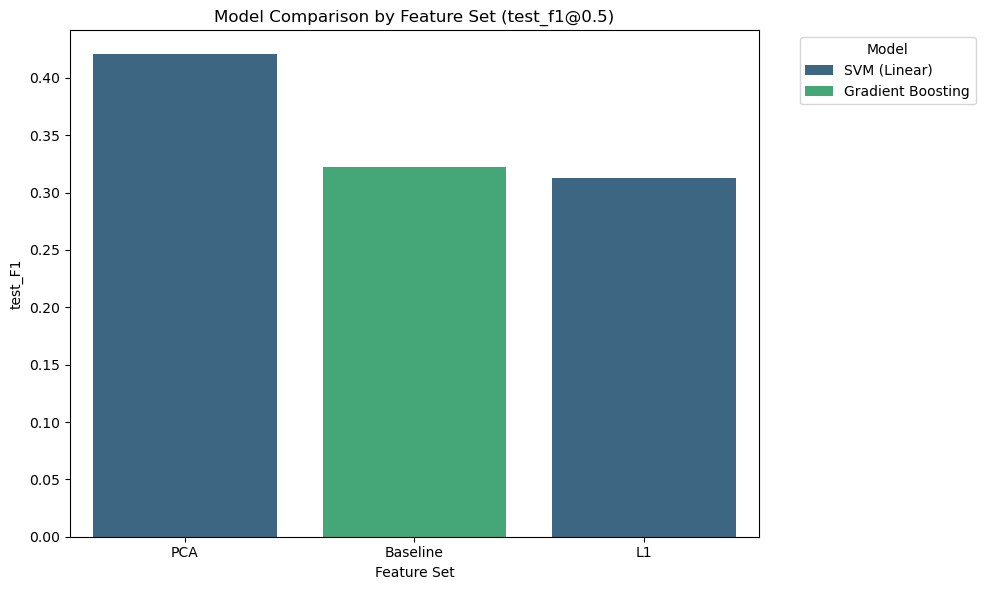

In [60]:
df_plot = test_results_top3.copy()
metric = 'test_f1@0.5'

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_plot,
    x='feature_set',
    y=metric,
    hue='model',
    palette='viridis'
)
plt.title(f'Model Comparison by Feature Set ({metric})')
plt.ylabel('test_F1')
plt.xlabel('Feature Set')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

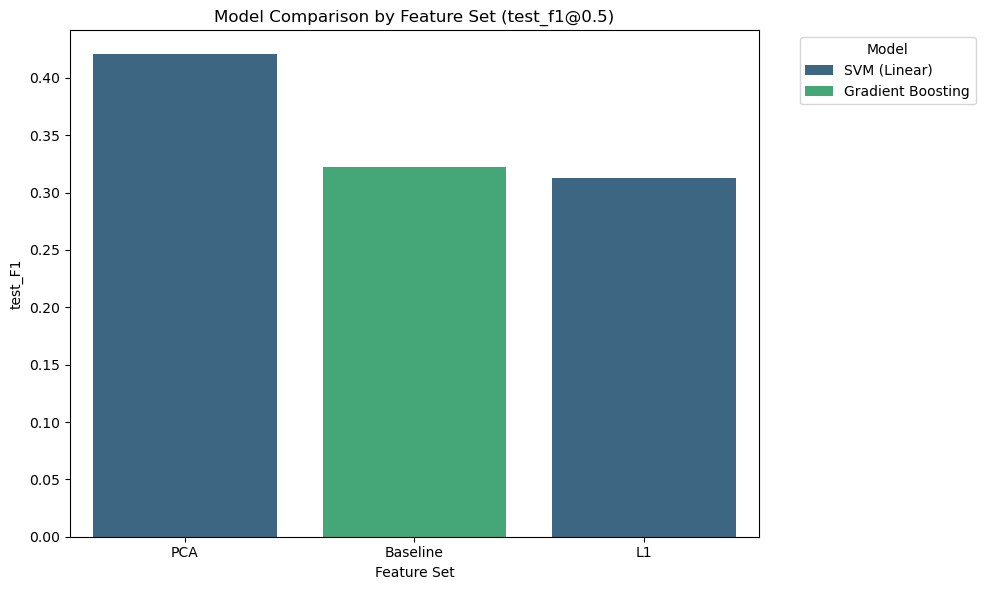

In [ ]:
df_plot = test_results_retrained.copy() if 'test_results_retrained' in locals() else test_results_no_retrain.copy()

metric = 'test_f1@0.5'

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_plot,
    x='feature_set',
    y=metric,
    hue='model',
    palette='viridis'
)
plt.title(f'Model Comparison by Feature Set ({metric})')
plt.ylabel('test_F1')
plt.xlabel('Feature Set')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

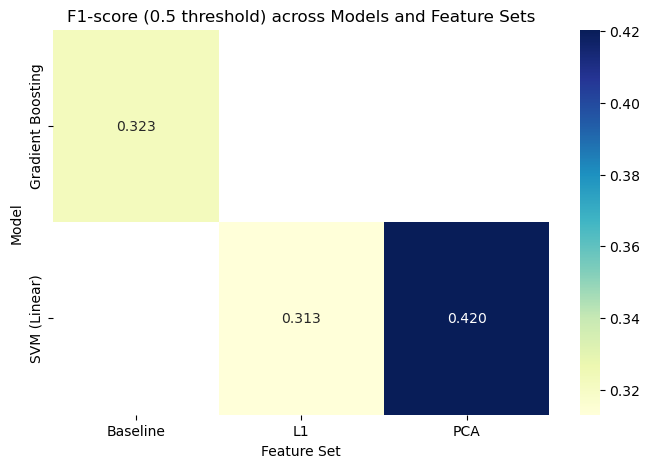

In [44]:
pivot_df = df_plot.pivot(index='model', columns='feature_set', values='test_f1@0.5')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap='YlGnBu')
plt.title("F1-score (0.5 threshold) across Models and Feature Sets")
plt.ylabel("Model")
plt.xlabel("Feature Set")
plt.show()

<Figure size 700x600 with 0 Axes>

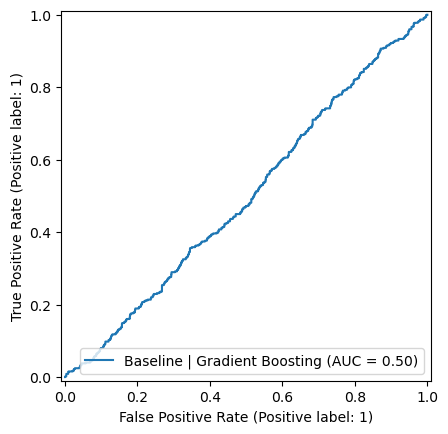

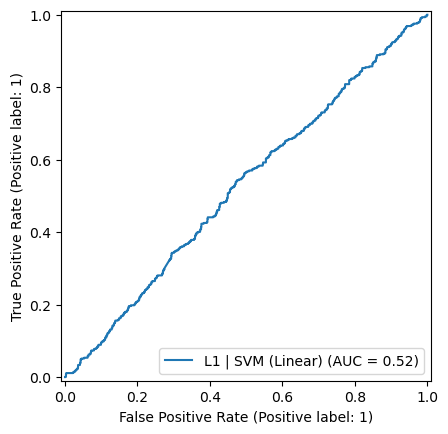

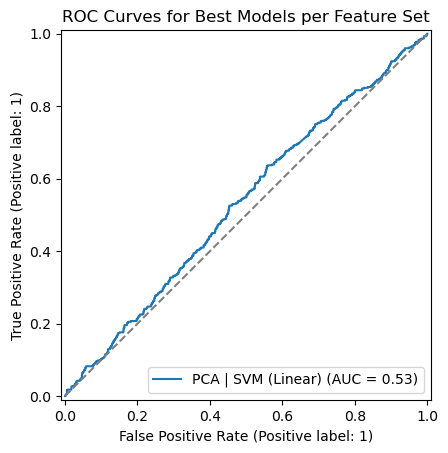

In [45]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 6))
for feat in ['Baseline', 'L1', 'PCA']:
    if (feat, winners.loc[winners['feature_set']==feat,'model'].values[0]) in best_models:
        model_name = winners.loc[winners['feature_set']==feat,'model'].values[0]
        best_est, _ = best_models[(feat, model_name)]
        Xte = {'Baseline': X_test_baseline, 'L1': X_test_L1, 'PCA': X_test_pca}[feat]
        RocCurveDisplay.from_estimator(best_est, Xte, y_test_array, name=f"{feat} | {model_name}")

plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC Curves for Best Models per Feature Set")
plt.legend(loc='lower right')
plt.show()

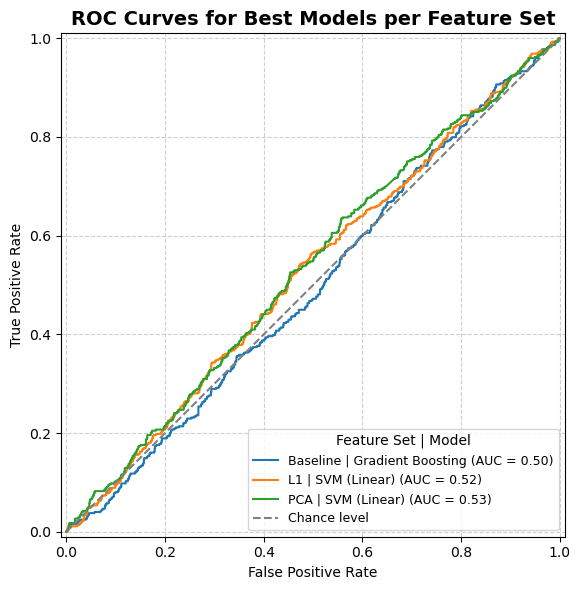

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = plt.gca() 

for feat in ['Baseline', 'L1', 'PCA']:
    
    if feat in winners['feature_set'].values:
        model_name = winners.loc[winners['feature_set'] == feat, 'model'].values[0]
        if (feat, model_name) in best_models:
            best_est, _ = best_models[(feat, model_name)]
            Xte = {'Baseline': X_test_baseline, 'L1': X_test_L1, 'PCA': X_test_pca}[feat]
            
            RocCurveDisplay.from_estimator(
                best_est,
                Xte,
                y_test_array,
                name=f"{feat} | {model_name}",
                ax=ax, 
                plot_chance_level=False
            )

# เส้น chance line (diagonal)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Chance level')

plt.title("ROC Curves for Best Models per Feature Set", fontsize=14, weight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(title="Feature Set | Model", loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

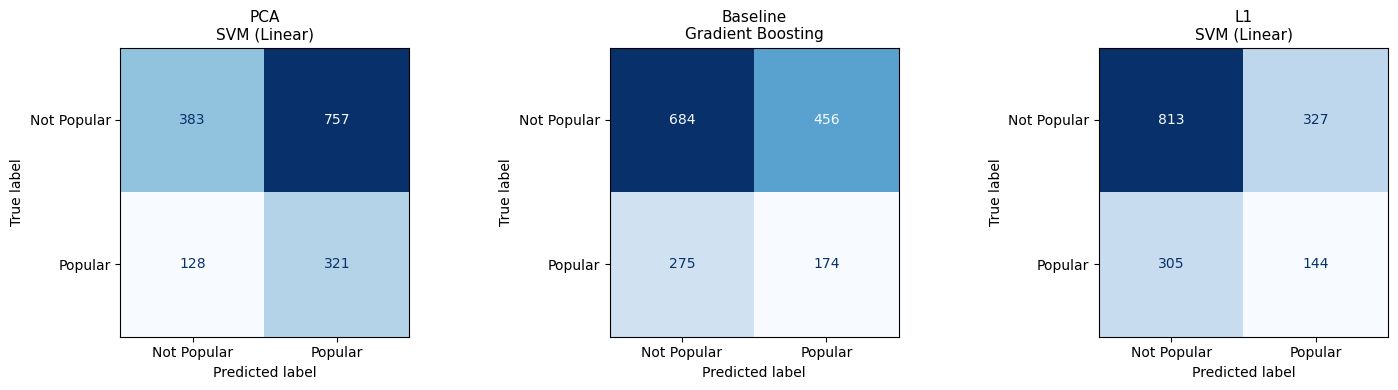

In [ ]:
test_maps = {
    'Baseline': X_test_baseline,
    'L1': X_test_L1,
    'PCA': X_test_pca,
}

plt.figure(figsize=(15, 4))

for i, (_, row) in enumerate(test_results_no_retrain.iterrows(), 1):
    feat = row['feature_set']
    model_name = row['model']
    
 
    best_est, best_t = best_models[(feat, model_name)]
    Xte = test_maps[feat]

    if hasattr(best_est, "predict_proba"):
        proba = best_est.predict_proba(Xte)[:, 1]
        y_pred = (proba >= 0.5).astype(int)
    elif hasattr(best_est, "decision_function"):
        score = best_est.decision_function(Xte)
        y_pred = (score >= 0.0).astype(int)
    else:
        y_pred = best_est.predict(Xte)
    
 
    cm = confusion_matrix(y_test_array, y_pred)
    
    plt.subplot(1, 3, i) 
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Popular', 'Popular'])
    disp.plot(ax=plt.gca(), cmap='Blues', colorbar=False)
    plt.title(f"{feat}\n{model_name}", fontsize=11)

plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import f1_score
import numpy as np

feat, model_name = 'PCA', 'SVM (Linear)'  # ตัวอย่าง
best_est, _ = best_models[(feat, model_name)]
Xva = X_val_pca

proba = best_est.predict_proba(Xva)[:, 1]
thresholds = np.linspace(0.1, 0.9, 17)
scores = [f1_score(y_val_array, (proba >= t).astype(int)) for t in thresholds]

best_t = thresholds[np.argmax(scores)]
print(f"Best threshold for {feat} | {model_name}: {best_t:.2f} (F1={max(scores):.3f})")

Best threshold for PCA | SVM (Linear): 0.40 (F1=0.460)
